# House Prices – Hybrid Notebook
A practical Kaggle notebook for learning ML fundamentals and submitting a competitive baseline.

## 1. Imports

In [117]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import (
    Ridge,
    Lasso,
    ElasticNet
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor


## 2. Load Data

In [118]:
# Kaggle paths
train = pd.read_csv('/Users/thuminh/Downloads/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/Users/thuminh/Downloads/house-prices-advanced-regression-techniques/test.csv')
sample_sub = pd.read_csv('/Users/thuminh/Downloads/house-prices-advanced-regression-techniques/sample_submission.csv')

print(train.shape, test.shape)
train.head()


(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Understand Dataset

In [119]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [120]:
train.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0


## 4. Target Variable Analysis

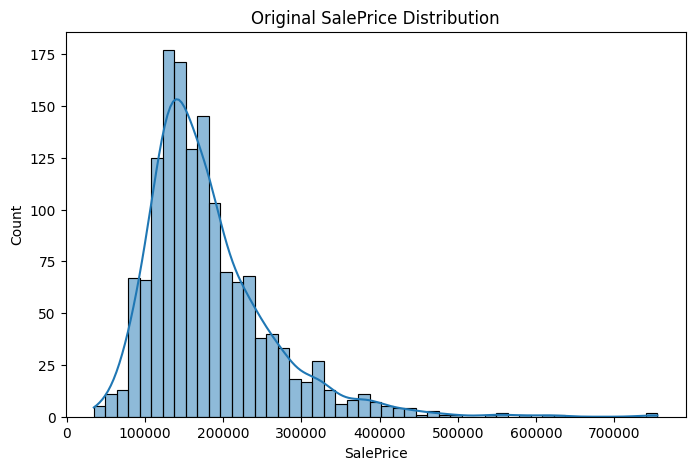

In [121]:
plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice'], kde=True)
plt.title('Original SalePrice Distribution')
plt.show()


Kaggle evaluates using log RMSE, so we log-transform the target.

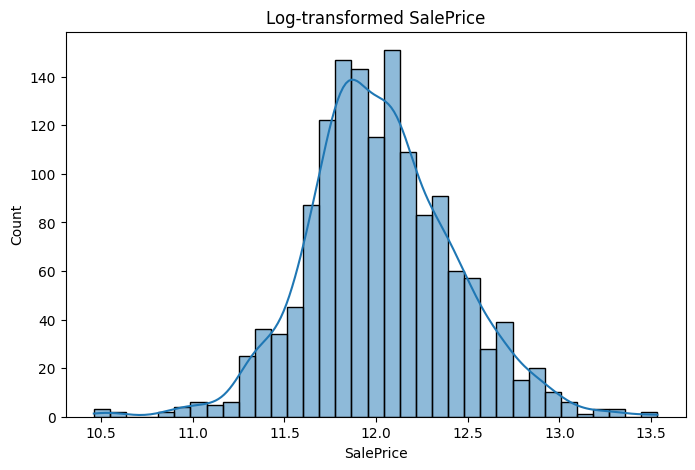

In [122]:
train['SalePrice'] = np.log1p(train['SalePrice'])

plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice'], kde=True)
plt.title('Log-transformed SalePrice')
plt.show()


## 5. Correlation with SalePrice

In [123]:
corr = train.corr(numeric_only=True)
sale_corr = corr['SalePrice'].sort_values(ascending=False)

sale_corr.head(15)


SalePrice       1.000000
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
TotRmsAbvGrd    0.534422
Fireplaces      0.489450
MasVnrArea      0.430809
BsmtFinSF1      0.372023
Name: SalePrice, dtype: float64

## 6. Missing Values

In [124]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing.head(20)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 7. Feature Engineering & Preprocessing

In [125]:
# Save IDs
train_ids = train['Id']
test_ids = test['Id']

# Drop ID
train.drop('Id', axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

# Target
y = train['SalePrice']

# Remove target from training features
train_features = train.drop('SalePrice', axis=1)

# Combine train + test for consistent preprocessing
full_data = pd.concat(
    [train_features, test],
    axis=0
)

full_data.shape


(2919, 79)

### Fill Missing Values

In [126]:
# Features where NA means 'not present'
none_cols = [
    'PoolQC','MiscFeature','Alley','Fence',
    'FireplaceQu','GarageType','GarageFinish',
    'GarageQual','GarageCond','BsmtQual',
    'BsmtCond','BsmtExposure','BsmtFinType1',
    'BsmtFinType2','MasVnrType'
]

for col in none_cols:
    if col in full_data.columns:
        full_data[col] = full_data[col].fillna('None')

# Numerical fill
num_fill_zero = [
    'GarageYrBlt','GarageArea','GarageCars',
    'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF',
    'TotalBsmtSF','BsmtFullBath','BsmtHalfBath',
    'MasVnrArea'
]

for col in num_fill_zero:
    if col in full_data.columns:
        full_data[col] = full_data[col].fillna(0)

# Mode fill for categorical
for col in full_data.select_dtypes(include='object').columns:
    full_data[col] = full_data[col].fillna(
        full_data[col].mode()[0]
    )

# Median fill for numerical
for col in full_data.select_dtypes(include=['int64','float64']).columns:
    full_data[col] = full_data[col].fillna(
        full_data[col].median()
    )


### Feature Engineering

In [127]:
full_data['HouseAge'] = (
    full_data['YrSold']
    - full_data['YearBuilt']
)

full_data['RemodelAge'] = (
    full_data['YrSold']
    - full_data['YearRemodAdd']
)

full_data['TotalSF'] = (
    full_data['TotalBsmtSF']
    + full_data['1stFlrSF']
    + full_data['2ndFlrSF']
)


### One-Hot Encoding

In [128]:
full_data = pd.get_dummies(full_data)

print(full_data.shape)


(2919, 305)


## 8. Split Back Train/Test

In [129]:
X = full_data.iloc[:len(train)]
X_test = full_data.iloc[len(train):]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_val.shape)


(1168, 305) (292, 305)


## 9. Ridge Regression

In [130]:
ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_val)

ridge_rmse = np.sqrt(
    mean_squared_error(y_val, ridge_pred)
)

print('Ridge RMSE:', ridge_rmse)


Ridge RMSE: 0.13664623240916274


## 10. Random Forest

In [131]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)

rf_rmse = np.sqrt(
    mean_squared_error(y_val, rf_pred)
)

print('RF RMSE:', rf_rmse)


RF RMSE: 0.14628400191009075


## 11. CatBoost


In [132]:
cat_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=200
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=200
)

cat_pred = cat_model.predict(X_val)

cat_rmse = np.sqrt(
    mean_squared_error(y_val, cat_pred)
)

print('CatBoost RMSE:', cat_rmse)


0:	learn: 0.3824486	test: 0.4247721	best: 0.4247721 (0)	total: 7.07ms	remaining: 21.2s
200:	learn: 0.1006950	test: 0.1398238	best: 0.1398238 (200)	total: 265ms	remaining: 3.69s
400:	learn: 0.0780229	test: 0.1291336	best: 0.1291336 (400)	total: 516ms	remaining: 3.35s
600:	learn: 0.0639885	test: 0.1275553	best: 0.1275013 (593)	total: 765ms	remaining: 3.05s
800:	learn: 0.0534550	test: 0.1271719	best: 0.1270739 (749)	total: 1.01s	remaining: 2.79s
1000:	learn: 0.0452088	test: 0.1270423	best: 0.1269151 (949)	total: 1.32s	remaining: 2.65s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1269150713
bestIteration = 949

Shrink model to first 950 iterations.
CatBoost RMSE: 0.12691506694156438


## 12. Lasso, elasticnet, lgbm, xgboost

In [133]:
lasso = Lasso(
    alpha=0.0005,
    random_state=42
)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_val)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lasso_pred
    )
)

print("Lasso RMSE:", lasso_rmse)

Lasso RMSE: 0.12888268189494448


In [134]:
elastic = ElasticNet(
    alpha=0.0005,
    l1_ratio=0.9,
    random_state=42
)

elastic.fit(X_train, y_train)

elastic_pred = elastic.predict(X_val)

elastic_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        elastic_pred
    )
)

print("ElasticNet RMSE:", elastic_rmse)

ElasticNet RMSE: 0.1282949531676566


In [135]:
lgb_model = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_val)

lgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lgb_pred
    )
)

print("LightGBM RMSE:", lgb_rmse)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003129 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3637
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 196
[LightGBM] [Info] Start training from score 12.030658
LightGBM RMSE: 0.1386960175218944


In [136]:
xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.01,
    reg_lambda=1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_pred
    )
)

print("XGBoost RMSE:", xgb_rmse)

XGBoost RMSE: 0.12996913743385324


In [137]:
scores = pd.DataFrame({
    "Model": [
        "Ridge",
        "Lasso",
        "ElasticNet",
        "RandomForest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "RMSE": [
        ridge_rmse,
        lasso_rmse,
        elastic_rmse,
        rf_rmse,
        xgb_rmse,
        lgb_rmse,
        cat_rmse
    ]
})

scores.sort_values("RMSE")

,Model,RMSE
6,CatBoost,0.126915
2,ElasticNet,0.128295
1,Lasso,0.128883
4,XGBoost,0.129969
0,Ridge,0.136646
5,LightGBM,0.138696
3,RandomForest,0.146284


In [138]:
# Train full-data models

ridge.fit(X, y)
lasso.fit(X, y)
elastic.fit(X, y)
rf.fit(X, y)
xgb_model.fit(X, y)
lgb_model.fit(X, y)
cat_model.fit(X, y)

# Predict
ridge_preds = ridge.predict(X_test)
lasso_preds = lasso.predict(X_test)
elastic_preds = elastic.predict(X_test)
rf_preds = rf.predict(X_test)
xgb_preds = xgb_model.predict(X_test)
lgb_preds = lgb_model.predict(X_test)
cat_preds = cat_model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3913
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 205
[LightGBM] [Info] Start training from score 12.024057
0:	learn: 0.3910351	total: 3.01ms	remaining: 9.03s
200:	learn: 0.1040951	total: 496ms	remaining: 6.91s
400:	learn: 0.0820908	total: 770ms	remaining: 4.99s
600:	learn: 0.0690230	total: 1.06s	remaining: 4.25s
800:	learn: 0.0592248	total: 1.39s	remaining: 3.83s
1000:	learn: 0.0514572	total: 1.73s	remaining: 3.46s
1200:	learn: 0.0447750	total: 2.05s	remaining: 3.07s
1400:	learn: 0.0392112	total: 2.52s	remaining: 2.88s
1600:	learn: 0.0347691	total: 2.82s	remaining: 2.47s
1800:	learn: 0.0309216	total: 3.16s	remain

In [139]:
rmse_scores = {
    "ridge": ridge_rmse,
    "lasso": lasso_rmse,
    "rf": rf_rmse,
    "xgb": xgb_rmse,
    "cat": cat_rmse
}

weights = {
    k: 1/v
    for k, v in rmse_scores.items()
}

# normalize
total = sum(weights.values())

weights = {
    k: v/total
    for k, v in weights.items()
}

print(weights)

{'ridge': np.float64(0.1952208957852003), 'lasso': np.float64(0.20698048414552594), 'rf': np.float64(0.1823589698686612), 'xgb': np.float64(0.20525026497283677), 'cat': np.float64(0.21018938522777575)}


In [140]:
ensemble_preds = (
    weights["ridge"] * ridge_preds
    + weights["lasso"] * lasso_preds
    + weights["rf"] * rf_preds
    + weights["xgb"] * xgb_preds
    + weights["cat"] * cat_preds
)

In [141]:
ensemble_preds = np.expm1(
    ensemble_preds
)

## 13. Create Submission

In [142]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": ensemble_preds
})

submission.to_csv(
    "submission.csv",
    index=False
)